# Linear Regression (Univariate) (Py / np)

### Hypothesis

In [1]:
import numpy as np 
import pandas as pd

In [2]:
def hypothesis(x, w, b):
    return w * x + b

### Cost Function

In [3]:
def compute_cost(x, y, w, b):

    m = x.shape[0]

    prediction = hypothesis(x,w,b)
    errors = prediction - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    
    return cost

### Gradient Descent

In [4]:
def compute_gradient(x, y , w, b):

    m = x.shape[0]

    prediction =  hypothesis(x,w,b)
    errors = prediction - y

    dw = (1 / m) * np.sum(errors * x)
    db = (1/m) * np.sum(errors)

    return dw,db

In [5]:
def GD(x,y,w,b, lr, iter):
    
    cost_hist = []

    for i in range(iter):
        dw, db = compute_gradient(x,y,w,b)

        w = w - lr * dw
        b = b - lr * db

        cost =  compute_cost(x,y, w, b)
        cost_hist.append(cost)
        
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}, w = {w:.4f}, b = {b:.4f}")

    return w,b , cost_hist

### Feature Scaling 

In [6]:
def feature_scale(x):
    mean = np.mean(x)
    std = np.std(x)

    x_scaled = (x - mean) / std

    return x_scaled, mean , std

### Convergence Checks

In [7]:
import matplotlib.pyplot as plt

In [8]:
def plot_cost(cost_history):
    plt.plot(cost_history)
    plt.xlabel("Iterations")
    plt.ylabel("cost(MSE)")
    plt.title("Gradient Descent convergence")
    plt.grid(True)
    plt.show()

### Cost Curve

In [9]:
def plot_regression_line(x, y, w, b, mean, std):
    x_scaled = (x - mean) / std
    
    y_pred = w * x_scaled + b
    
    plt.scatter(x, y, color='blue', label="Actual Data")
    plt.plot(x, y_pred, color='red', label="Hypothesis (Model Prediction)")
    
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Linear Regression Fit")
    plt.legend()
    plt.grid(True)
    plt.show()


### Final block

Iteration 0: Cost = 306.933567, w = 0.0029, b = 0.0183
Iteration 100: Cost = 275.768904, w = 0.2764, b = 1.7621
Iteration 200: Cost = 250.255989, w = 0.5239, b = 3.3398
Iteration 300: Cost = 229.369871, w = 0.7479, b = 4.7673
Iteration 400: Cost = 212.271474, w = 0.9505, b = 6.0589
Iteration 500: Cost = 198.273892, w = 1.1338, b = 7.2275
Iteration 600: Cost = 186.814788, w = 1.2997, b = 8.2849
Iteration 700: Cost = 177.433806, w = 1.4498, b = 9.2416
Iteration 800: Cost = 169.754076, w = 1.5855, b = 10.1072
Iteration 900: Cost = 163.467074, w = 1.7084, b = 10.8904
Iteration 1000: Cost = 158.320227, w = 1.8196, b = 11.5990
Iteration 1100: Cost = 154.106767, w = 1.9201, b = 12.2402
Iteration 1200: Cost = 150.657423, w = 2.0112, b = 12.8203
Iteration 1300: Cost = 147.833621, w = 2.0935, b = 13.3452
Iteration 1400: Cost = 145.521919, w = 2.1680, b = 13.8201
Iteration 1500: Cost = 143.629447, w = 2.2354, b = 14.2498
Iteration 1600: Cost = 142.080177, w = 2.2964, b = 14.6386
Iteration 1700: C

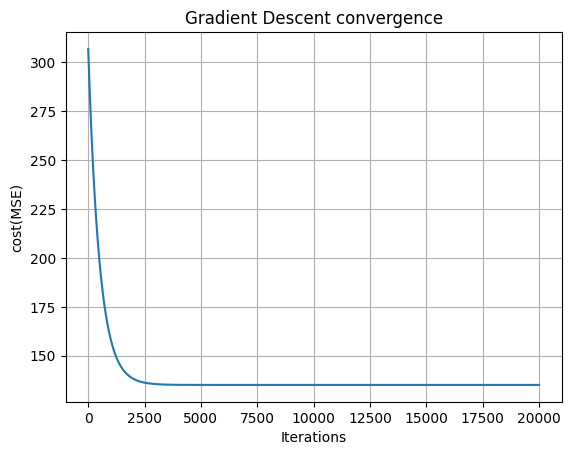

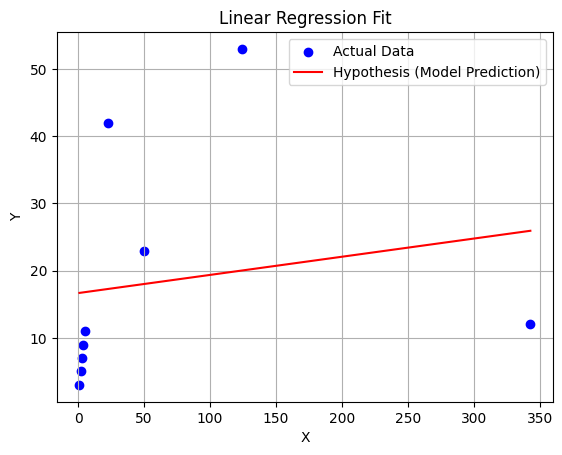

In [10]:
x = np.array([1, 2, 3, 4, 5, 23,50,124,343], dtype=float)
y = np.array([3, 5, 7, 9, 11, 42,23,53,12], dtype=float) 

x_scaled, mean, std = feature_scale(x)
w = 0.0
b = 0.0

lr = 0.001
iter = 20000

w_final, b_final, cost_history = GD(
    x_scaled, y, w, b, lr, iter
)

print("TRAINING COMPLETE")
print("Final w:", w_final)
print("Final b:", b_final)

plot_cost(cost_history)
plot_regression_line(x, y, w_final, b_final, mean, std)